# Notebook 2: Exploración y Hallazgos

En esta sección realizaremos un Análisis Exploratorio de Datos (EDA) para visualizar y responder preguntas clave sobre el uso de GitHub Agentic Workflows en los repositorios identificados.

## 1. Preparación del entorno
Volvemos a cargar las tablas y preparamos las librerías de visualización (Matplotlib y Seaborn).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Cargar los datos desde los archivos Parquet
df_repos = pd.read_parquet("../dataset/repositorios.parquet")
df_archivos = pd.read_parquet("../dataset/archivos.parquet")
df_frontmatter = pd.read_parquet("../dataset/frontmatter.parquet")

print("✅ Datos cargados y entorno de visualización listo.")

✅ Datos cargados y entorno de visualización listo.


## 2. Volumen de Workflows por Repositorio
¿Cuántos archivos de GH-AW implementa cada proyecto en promedio? ¿Cuáles son los repositorios que hacen un uso más intensivo de esta herramienta?

Estadísticas del uso de archivos por repositorio:
count    28.000000
mean      4.642857
std       7.082656
min       1.000000
25%       1.000000
50%       2.000000
75%       5.000000
max      36.000000
Name: cantidad_archivos, dtype: float64


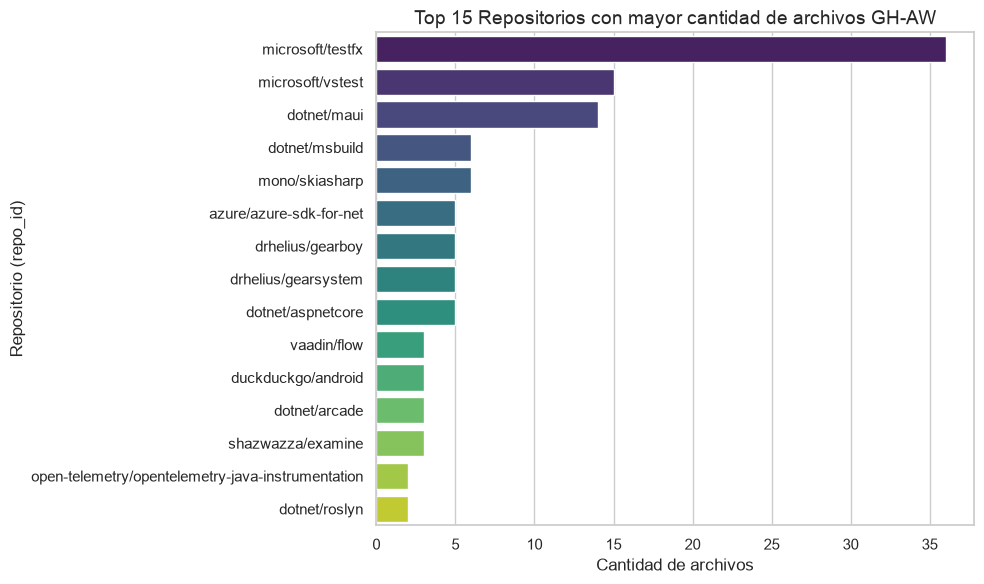

In [3]:
# Contar cuántos archivos tiene cada repositorio
archivos_por_repo = df_archivos.groupby('repo_id').size().reset_index(name='cantidad_archivos')

# Ordenar de mayor a menor y tomar los 15 primeros para que el gráfico sea legible
top_repos = archivos_por_repo.sort_values('cantidad_archivos', ascending=False).head(15)

# Imprimir estadísticas descriptivas rápidas
print("Estadísticas del uso de archivos por repositorio:")
print(archivos_por_repo['cantidad_archivos'].describe())

# Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.barplot(data=top_repos, x='cantidad_archivos', y='repo_id', hue='repo_id', palette='viridis', legend=False)

plt.title('Top 15 Repositorios con mayor cantidad de archivos GH-AW', fontsize=14)
plt.xlabel('Cantidad de archivos', fontsize=12)
plt.ylabel('Repositorio (repo_id)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Análisis de Propiedades (Frontmatter)

Cada archivo Markdown de GH-AW incluye un bloque de configuración inicial (YAML frontmatter). ¿Cuáles son las propiedades (claves) más utilizadas por los desarrolladores para configurar estos flujos de trabajo?

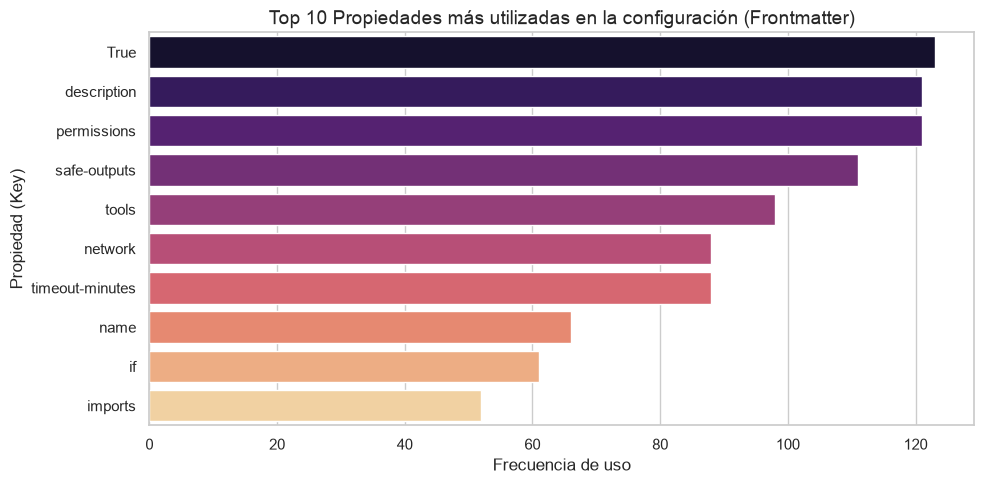

In [4]:
# Contar la frecuencia de cada clave (key) en el frontmatter
top_keys = df_frontmatter['key'].value_counts().head(10).reset_index()
top_keys.columns = ['key', 'frecuencia']

# Crear el gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(data=top_keys, x='frecuencia', y='key', hue='key', palette='magma', legend=False)

plt.title('Top 10 Propiedades más utilizadas en la configuración (Frontmatter)', fontsize=14)
plt.xlabel('Frecuencia de uso', fontsize=12)
plt.ylabel('Propiedad (Key)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Análisis del Contenido (Body)

Finalmente, analizaremos la longitud del contenido de los archivos (cantidad de caracteres en el `body`). Esto nos ayudará a entender si la mayoría de los desarrolladores escriben flujos de trabajo cortos y concisos, o si tienden a crear scripts muy extensos.

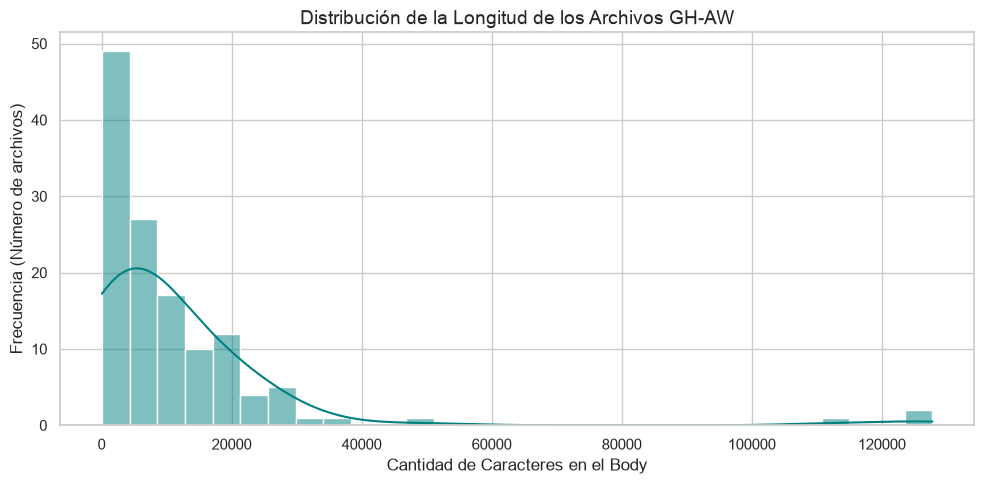

► Longitud promedio: 11655 caracteres.
► Archivo más largo: 127791 caracteres.


In [5]:
# Calcular la longitud (cantidad de caracteres) del contenido de cada archivo
df_archivos['longitud_body'] = df_archivos['body'].apply(len)

# Crear un histograma para visualizar la distribución
plt.figure(figsize=(10, 5))
sns.histplot(data=df_archivos, x='longitud_body', bins=30, kde=True, color='teal')

plt.title('Distribución de la Longitud de los Archivos GH-AW', fontsize=14)
plt.xlabel('Cantidad de Caracteres en el Body', fontsize=12)
plt.ylabel('Frecuencia (Número de archivos)', fontsize=12)
plt.tight_layout()
plt.show()

# Mostrar algunas estadísticas extra
promedio = df_archivos['longitud_body'].mean()
maximo = df_archivos['longitud_body'].max()
print(f"► Longitud promedio: {promedio:.0f} caracteres.")
print(f"► Archivo más largo: {maximo} caracteres.")